# **Soliton Solutions to the Korteweg–De Vries (KdV) equation**

Here we present a brief example of how the code is used to solve the KdV equation for one- and two-soliton solutions using physics-informed neural networks.

**Setup:**

In [1]:
import torch
import torch.nn as nn

import sys
from pathlib import Path

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

from models import KDV

Check GPU availability:

In [2]:
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

CUDA available: True


## **One soliton**

Configure and train a model for a single soliton:

In [3]:
INIT_PARAMS = dict(
    num_solitons             = 1,
    n_hidden_layers          = 4, 
    n_neurons_per_layer      = 32, 
    activation               = nn.Tanh,
    seed                     = 42, 
    verbose                  = True,
)

TRAIN_PARAMS = dict(
    adam_epochs              = 1000,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,  
    w_ic                     = 5.0,    
    w_bc                     = 1.0,    
    w_pde                    = 15.0,   
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100,    
    adaptive_sampling        = False,   
)

Create an instance of the class:

In [4]:
model = KDV(INIT_PARAMS)

Using device: cuda
Testing domain created with 1000x1000 grid points.
[gpu mem] after __init__            alloc     0.0 MB  reserved     2.0 MB  peak     0.0 MB


Train the model:

In [5]:
model.train(TRAIN_PARAMS)

[gpu mem] after setup_training_domain alloc     0.9 MB  reserved     2.0 MB  peak     0.9 MB
Training domain setup complete: 
                    - 50000 collocation points
                    - 30000 initial points
                    - 10000 boundary points
Using 1-soliton initial condition.
Solving over the domain: t: (-15, 15), x: (-30, 30)


/home/jairdan/miniconda3/envs/soliton-pinn/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Weighted losses [start]: IC=1.445e+00, BC=5.566e-01, PDE=2.428e-01
Starting Adam optimization...
[gpu mem] train start               alloc    18.1 MB  reserved   788.0 MB  peak    18.1 MB
Adam - Epoch 0/1000, Total Loss: 2.244153e+00
Adam - Epoch 100/1000, Total Loss: 1.018373e-02
Adam - Epoch 200/1000, Total Loss: 5.134629e-03
Adam - Epoch 300/1000, Total Loss: 2.476273e-03
Adam - Epoch 400/1000, Total Loss: 1.299950e-03
Adam - Epoch 500/1000, Total Loss: 7.866869e-04
Adam - Epoch 600/1000, Total Loss: 5.328881e-04
Adam - Epoch 700/1000, Total Loss: 3.903051e-04
Adam - Epoch 800/1000, Total Loss: 3.045517e-04
Adam - Epoch 900/1000, Total Loss: 2.497810e-04
Adam - Epoch 999/1000, Total Loss: 2.127635e-04
[gpu mem] after Adam                alloc    18.9 MB  reserved   828.0 MB  peak   743.1 MB

Starting L-BFGS optimization...
L-BFGS - Iteration 100, Total Loss: 4.701797e-05
L-BFGS - Iteration 200, Total Loss: 2.278574e-05
L-BFGS - Iteration 300, Total Loss: 1.196271e-05
L-BFGS - Iterat

Let's plot how training progressed:

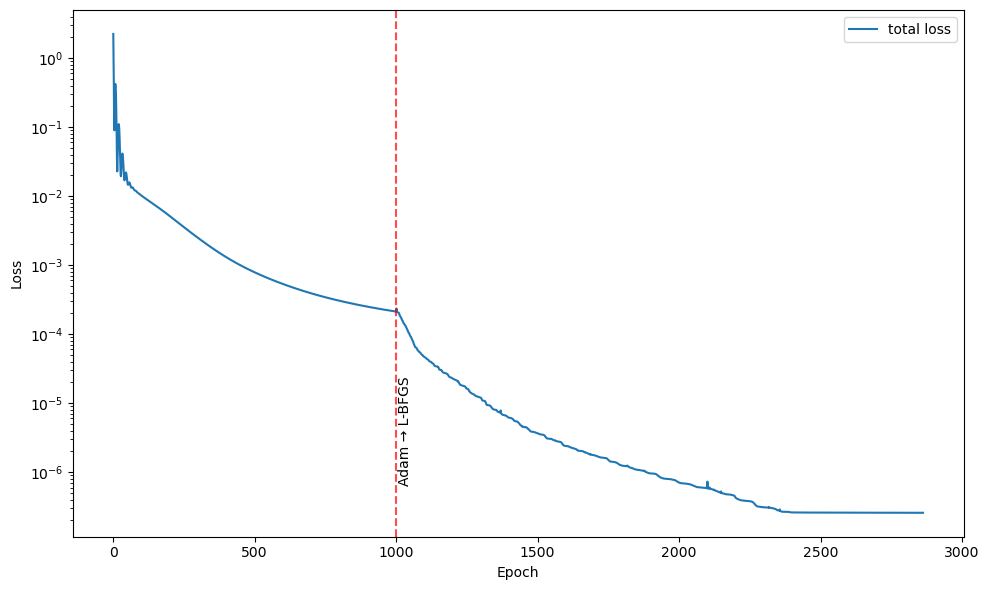

In [6]:
model.plot_losses()

Visualize the results:

[gpu mem] inside compute_solutions  alloc    18.1 MB  reserved    46.0 MB  peak   748.3 MB


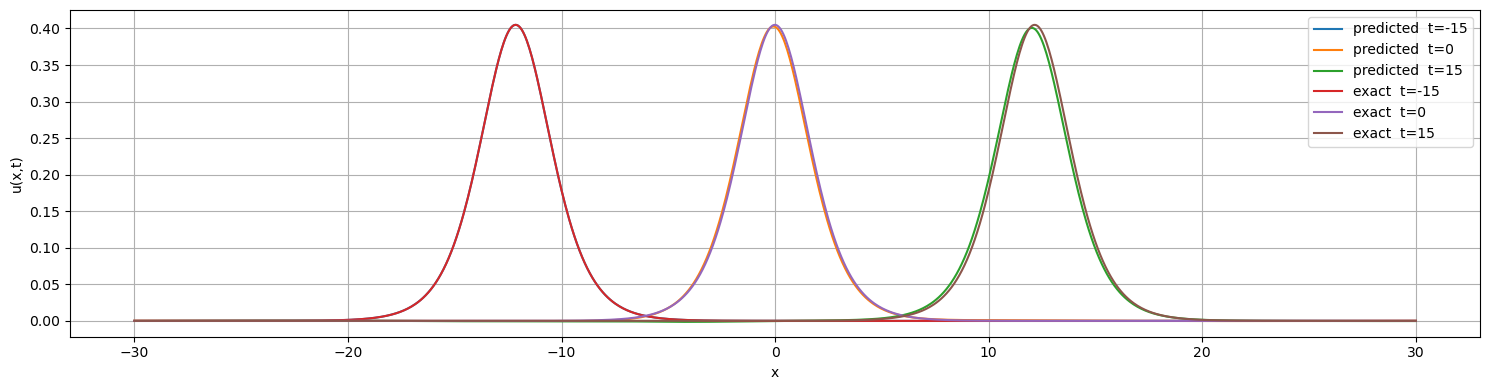

In [7]:
model.plot_profiles(t_values=[-15, 0, 15], solutions=("predicted", "exact"))

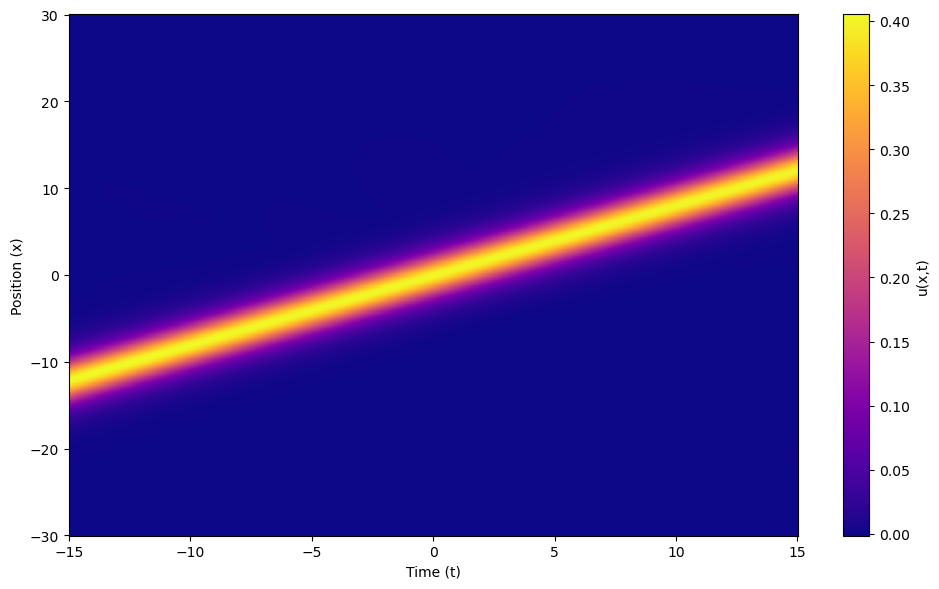

In [8]:
model.plot_spacetime()

We can also use the test method to view the point-wise error over the domain and also compute the mean and max error. Multiple error types are available, including `absolute` and `absolute-normalized`.

absolute-normalized error metrics:
Mean: 2.562180e-03
Maximum: 4.818631e-02


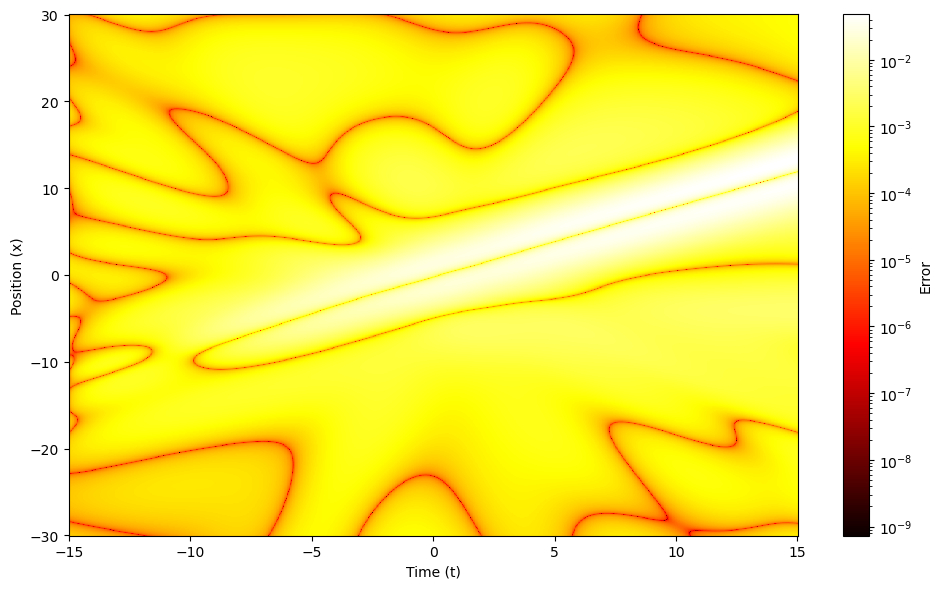

In [9]:
model.test(plot_heatmap=True)

## **Two solitons**

Configure and train for two colliding solitons:

In [10]:
INIT_PARAMS_2 = dict(
    num_solitons=2,
    n_hidden_layers=7, 
    n_neurons_per_layer=62, 
    activation=nn.Tanh,
    seed=82, 
    verbose=True,
)

TRAIN_PARAMS_2 = dict(
    adam_epochs=1000,
    verbose_step=100,
    n_collocation=100000, 
    n_initial=10000,  
    n_boundary=10000,  
    w_ic=10.0,    
    w_bc=1.0,    
    w_pde=100.0,   
    adam_lr=1e-3,   
    lbfgs_lr=2.0,    
    lbfgs_history_size=295,    
    adaptive_sampling=False,   
    lbfgs_version='old'
)

model_2 = KDV(INIT_PARAMS_2)
model_2.train(TRAIN_PARAMS_2)

Using device: cuda
Testing domain created with 1000x1000 grid points.
[gpu mem] after __init__            alloc    18.2 MB  reserved    46.0 MB  peak   748.3 MB
[gpu mem] after setup_training_domain alloc    19.2 MB  reserved    46.0 MB  peak   748.3 MB
Training domain setup complete: 
                    - 100000 collocation points
                    - 10000 initial points
                    - 10000 boundary points
Using 2-soliton initial condition.
Solving over the domain: t: (-20, 35), x: (-35, 50)
Weighted losses [start]: IC=2.246e-01, BC=1.571e-02, PDE=5.503e-02
Starting Adam optimization...
[gpu mem] train start               alloc    19.2 MB  reserved  4470.0 MB  peak    19.2 MB
Adam - Epoch 0/1000, Total Loss: 2.953535e-01
Adam - Epoch 100/1000, Total Loss: 2.786514e-02
Adam - Epoch 200/1000, Total Loss: 6.902860e-03
Adam - Epoch 300/1000, Total Loss: 3.261578e-03
Adam - Epoch 400/1000, Total Loss: 2.096157e-03
Adam - Epoch 500/1000, Total Loss: 1.973270e-03
Adam - Epoch 600/

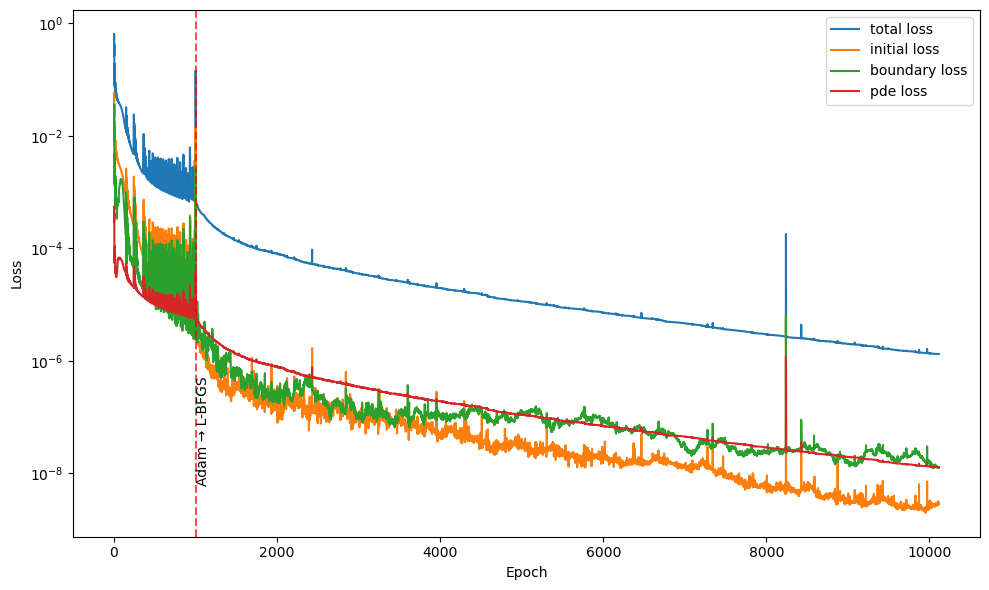

In [11]:
model_2.plot_losses(component='all')

[gpu mem] inside compute_solutions  alloc    19.3 MB  reserved    48.0 MB  peak  4593.0 MB


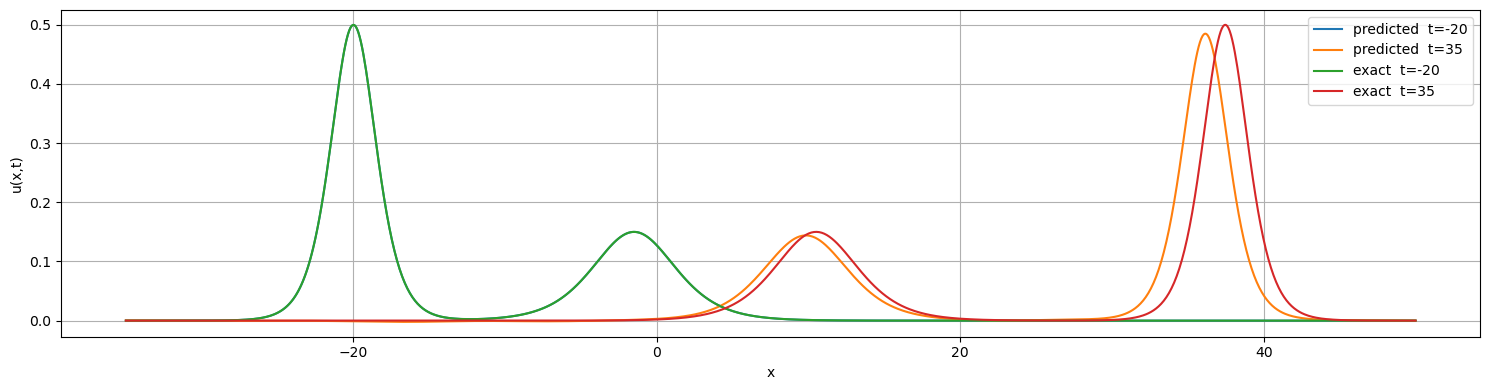

In [12]:
model_2.plot_profiles(t_values=[-20, 35], solutions=("predicted", "exact"))

absolute-normalized error metrics:
Mean: 1.440542e-02
Maximum: 4.728145e-01


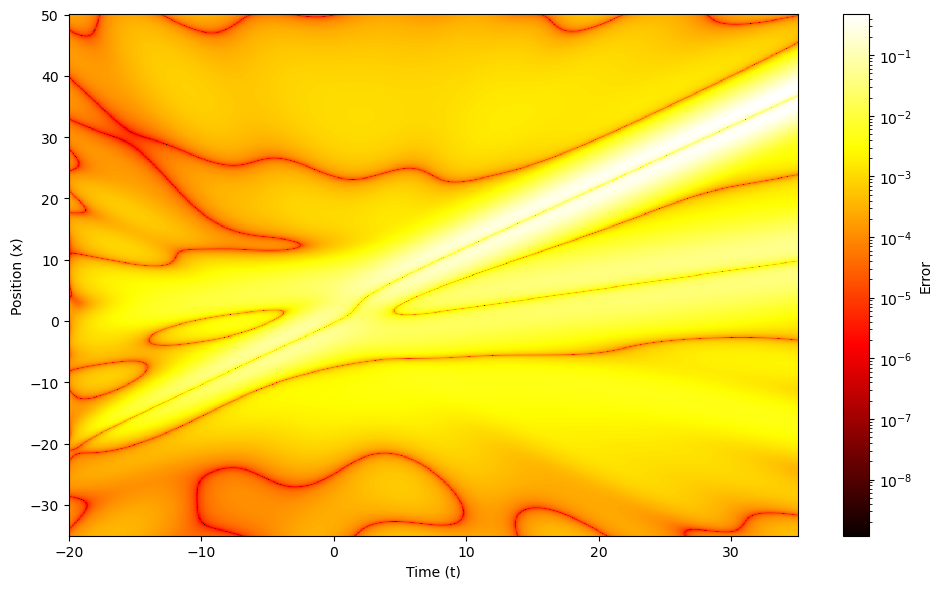

In [13]:
model_2.test(plot_heatmap=True)

## Saving Results

The results for a trained model can be saved using: 

```python
model.save_model_result("results/model.json")
```

The saved JSON contains the full solution, domain, and configuration. 